
# Edge AI Assignment: Neural Network from Scratch (Checkerboard Classification)

## Objective
Build a simple neural network **from scratch (no ML libraries)** to classify a 2D checkerboard pattern.

You will:
- Implement forward propagation
- Implement backpropagation
- Train a small neural network
- Visualize the decision boundary

---

## Dataset Concept
We generate (x, y) points and assign labels based on a checkerboard pattern.

This is a **non-linear classification problem** (like XOR, but extended to 2D).


In [1]:

import numpy as np
import matplotlib.pyplot as plt


## Step 1: Generate Checkerboard Data

In [2]:

def generate_data(n_samples=500, k=4):
    X = np.random.uniform(-1, 1, (n_samples, 2))

    # Checkerboard labels
    y = ((np.floor((X[:,0]+1)*k) + np.floor((X[:,1]+1)*k)) % 2)

    return X, y.reshape(-1, 1)

X, y = generate_data()


## Visualize Dataset

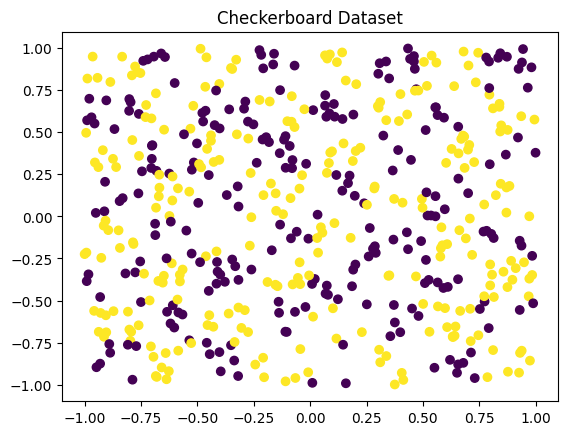

In [3]:

plt.scatter(X[:,0], X[:,1], c=y.flatten())
plt.title("Checkerboard Dataset")
plt.show()



## Step 2: Build Neural Network

Architecture:
- Input: 2 neurons (x, y)
- Hidden: YOU DECIDE
- Output: 1 neuron (sigmoid)

Fill in missing parts.


In [4]:

# Initialize weights
def init_params(input_size, hidden_size, output_size):
    W1 = np.random.randn(input_size, hidden_size)
    b1 = np.zeros((1, hidden_size))

    W2 = np.random.randn(hidden_size, output_size)
    b2 = np.zeros((1, output_size))

    return W1, b1, W2, b2


## Activation Functions

In [5]:

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)


## Forward Pass

In [6]:

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1          # (n, hidden)
    A1 = sigmoid(Z1)           # (n, hidden)
    Z2 = A1 @ W2 + b2          # (n, 1)
    A2 = sigmoid(Z2)           # (n, 1)
    cache = (Z1, A1, Z2, A2)
    return A2, cache


## Loss Function

In [7]:

def compute_loss(y_true, y_pred):
    n = y_true.shape[0]
    eps = 1e-8  # avoid log(0)
    loss = -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))
    return loss


## Backpropagation

In [8]:

def backward(X, y, W1, b1, W2, b2, cache):
    n = X.shape[0]
    Z1, A1, Z2, A2 = cache

    # Output layer gradients
    dZ2 = A2 - y                              # BCE + sigmoid simplification
    dW2 = (A1.T @ dZ2) / n
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    # Hidden layer gradients
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = (X.T @ dZ1) / n
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


## Training Loop

In [9]:

def train(X, y, hidden_size=16, lr=0.1, epochs=2000):
    W1, b1, W2, b2 = init_params(2, hidden_size, 1)

    for epoch in range(epochs):
        # Forward
        y_pred, cache = forward(X, W1, b1, W2, b2)

        # Loss
        loss = compute_loss(y, y_pred)

        # Backward
        dW1, db1, dW2, db2 = backward(X, y, W1, b1, W2, b2, cache)

        # Update weights
        W1 -= lr * dW1
        b1 -= lr * db1
        W2 -= lr * dW2
        b2 -= lr * db2

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")

    return W1, b1, W2, b2


## Visualize Decision Boundary

In [10]:

def plot_decision_boundary(X, y, model):
    xx, yy = np.meshgrid(np.linspace(-1,1,100), np.linspace(-1,1,100))
    grid = np.c_[xx.ravel(), yy.ravel()]

    W1, b1, W2, b2 = model
    Z, _ = forward(grid, W1, b1, W2, b2)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.5)
    plt.scatter(X[:,0], X[:,1], c=y.flatten())
    plt.title("Decision Boundary")
    plt.show()


## Run Training

Epoch 0, Loss: 2.2495
Epoch 100, Loss: 0.6980
Epoch 200, Loss: 0.6895
Epoch 300, Loss: 0.6887
Epoch 400, Loss: 0.6886
Epoch 500, Loss: 0.6886
Epoch 600, Loss: 0.6885
Epoch 700, Loss: 0.6885
Epoch 800, Loss: 0.6884
Epoch 900, Loss: 0.6884
Epoch 1000, Loss: 0.6883
Epoch 1100, Loss: 0.6883
Epoch 1200, Loss: 0.6882
Epoch 1300, Loss: 0.6881
Epoch 1400, Loss: 0.6881
Epoch 1500, Loss: 0.6880
Epoch 1600, Loss: 0.6880
Epoch 1700, Loss: 0.6879
Epoch 1800, Loss: 0.6879
Epoch 1900, Loss: 0.6878


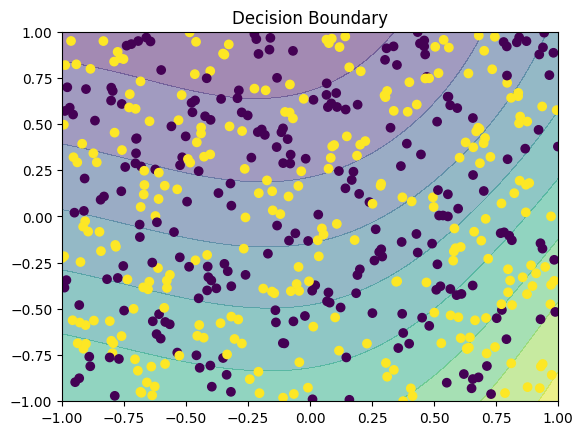

In [11]:

# Train your model
model = train(X, y)

plot_decision_boundary(X, y, model)



---

## ⭐ Extra Credit ( For Concept And Code, 20% add on )

### Circle Classification Problem

Instead of a checkerboard, classify points based on whether they lie inside a circle:

- Input: (x, y)
- Output: 1 if inside circle, else 0

Decision boundary:
x² + y² < r²

### Questions:
1. Why is this non-linear?
2. Would a single-layer perceptron work?
3. How would the decision boundary differ from the checkerboard?

---

